# Aviation Passenger Demand Forecasting

## Project Goal

This project investigates whether historical monthly passenger traffic can be used to forecast future passenger demand at San Francisco International Airport.

The project uses historical SFO passenger statistics and compares several machine learning approaches, including a simple baseline, Linear Regression, and Random Forest.

The project focuses on time-series feature engineering and chronological model evaluation.

In [ ]:
# 1. Project Objective

# 2. Import Libraries

# 3. Load Dataset

# 4. Initial Dataset Inspection

# 5. Understand the Variables

# 6. Data Quality Checks

# 7. Initial Observations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("data/SF_Air_Traffic_Passenger_Statistics.csv")

In [10]:
df.head()

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,"31,432",2026/08/20 01:00:20 PM,2026/08/22 03:04:26 PM
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,"31,353",2026/08/20 01:00:20 PM,2026/08/22 03:04:26 PM
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,"2,518",2026/08/20 01:00:20 PM,2026/08/22 03:04:26 PM
3,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,"1,324",2026/08/20 01:00:20 PM,2026/08/22 03:04:26 PM
4,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,"1,198",2026/08/20 01:00:20 PM,2026/08/22 03:04:26 PM


In [8]:
df.shape

(40450, 15)

In [11]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 40,450
Columns: 15


In [12]:
df.columns

Index(['Activity Period', 'Activity Period Start Date', 'Operating Airline',
       'Operating Airline IATA Code', 'Published Airline',
       'Published Airline IATA Code', 'GEO Summary', 'GEO Region',
       'Activity Type Code', 'Price Category Code', 'Terminal',
       'Boarding Area', 'Passenger Count', 'data_as_of', 'data_loaded_at'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40450 entries, 0 to 40449
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Activity Period              40450 non-null  int64
 1   Activity Period Start Date   40450 non-null  str  
 2   Operating Airline            40450 non-null  str  
 3   Operating Airline IATA Code  40134 non-null  str  
 4   Published Airline            40450 non-null  str  
 5   Published Airline IATA Code  40134 non-null  str  
 6   GEO Summary                  40450 non-null  str  
 7   GEO Region                   40450 non-null  str  
 8   Activity Type Code           40450 non-null  str  
 9   Price Category Code          40450 non-null  str  
 10  Terminal                     40450 non-null  str  
 11  Boarding Area                40450 non-null  str  
 12  Passenger Count              40450 non-null  str  
 13  data_as_of                   40450 non-null  str  
 14  d

In [14]:
df.describe(include="all")

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
count,40450.000000,40450,40450,40134,40450,40134,40450,40450,40450,40450,40450,40450,40450,40450,40450
unique,NaN,324,140,116,126,105,2,9,3,2,5,8,23345,2,1
top,NaN,2026/06/01,United Airlines,UA,United Airlines,UA,International,US,Enplaned,Other,International,A,1,2026/08/20 01:00:21 PM,2026/08/22 03:04:26 PM
freq,NaN,179,4795,8465,5507,9824,26519,13931,19217,36230,25186,14553,23,34866,40450
mean,201343.974932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,793.195691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,199907.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,200702.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,201405.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,202008.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.isnull().sum()

Activity Period                  0
Activity Period Start Date       0
Operating Airline                0
Operating Airline IATA Code    316
Published Airline                0
Published Airline IATA Code    316
GEO Summary                      0
GEO Region                       0
Activity Type Code               0
Price Category Code              0
Terminal                         0
Boarding Area                    0
Passenger Count                  0
data_as_of                       0
data_loaded_at                   0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [20]:
df["Activity Period"].head(10)

0    199907
1    199907
2    199907
3    199907
4    199907
5    199907
6    199907
7    199907
8    199907
9    199907
Name: Activity Period, dtype: int64

In [21]:
df.columns

Index(['Activity Period', 'Activity Period Start Date', 'Operating Airline',
       'Operating Airline IATA Code', 'Published Airline',
       'Published Airline IATA Code', 'GEO Summary', 'GEO Region',
       'Activity Type Code', 'Price Category Code', 'Terminal',
       'Boarding Area', 'Passenger Count', 'data_as_of', 'data_loaded_at'],
      dtype='str')

In [24]:
df["Passenger Count"].describe()

count     40450
unique    23345
top           1
freq         23
Name: Passenger Count, dtype: object

In [26]:
df["Operating Airline"].nunique()

140

In [27]:
df["Operating Airline"].value_counts().head(10)

Operating Airline
United Airlines                     4795
United Airlines - Pre 07/01/2013    3670
SkyWest Airlines                    2353
Alaska Airlines                     1924
Delta Air Lines                      859
American Airlines                    773
Air Canada                           752
Frontier Airlines                    711
Southwest Airlines                   695
EVA Airways                          648
Name: count, dtype: int64

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(df["Passenger Count"], bins=50)

plt.xlabel("Passenger Count")
plt.ylabel("Frequency")
plt.title("Distribution of Passenger Counts")

plt.show()

In [30]:
print(df.shape)
print(df["Passenger Count"].head())

(40450, 15)
0    31,432
1    31,353
2     2,518
3     1,324
4     1,198
Name: Passenger Count, dtype: str


In [31]:
df["Passenger Count"] = df["Passenger Count"].str.replace(",", "").astype(int)

In [32]:
print(df["Passenger Count"].dtype)

int64


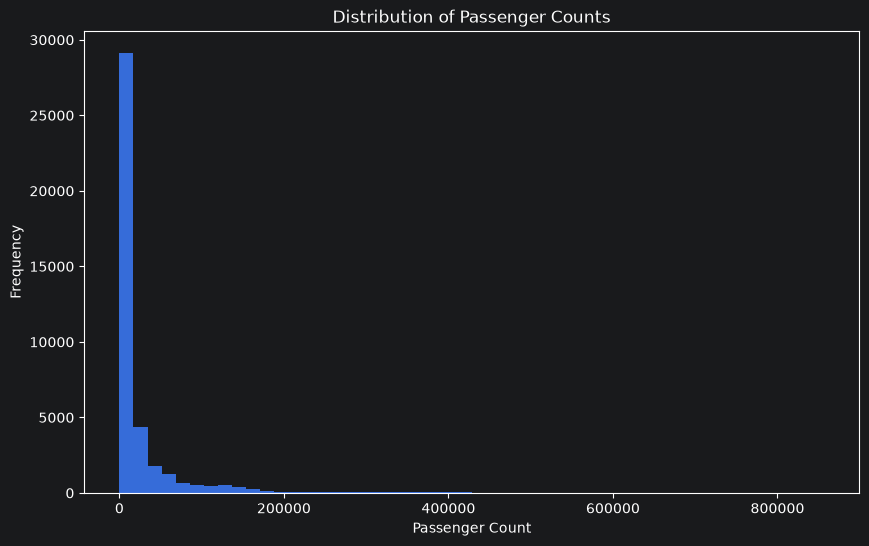

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(df["Passenger Count"], bins=50)

plt.xlabel("Passenger Count")
plt.ylabel("Frequency")
plt.title("Distribution of Passenger Counts")

plt.show()

In [19]:
print(df.columns.tolist())

['Activity Period', 'Activity Period Start Date', 'Operating Airline', 'Operating Airline IATA Code', 'Published Airline', 'Published Airline IATA Code', 'GEO Summary', 'GEO Region', 'Activity Type Code', 'Price Category Code', 'Terminal', 'Boarding Area', 'Passenger Count', 'data_as_of', 'data_loaded_at']


## Initial Observations

1. The dataset contains 40450 rows and 15 columns.

2. The data contains monthly passenger activity at San Francisco International Airport.

3. The dataset contains information about operating airlines and passenger counts.


5. The dataset seems to contain seasonal patterns that should be investigated further.

6. Before modelling, the raw data will need to be aggregated into a suitable monthly time series.